## Build a Mini U-net from scratch and Test Hooks 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch 
import torch.nn as nn 

### Mini U-net class 

In [3]:
class MiniUNet(nn.Module) : 
    def __init__(self ) : 
        super().__init__()
        self.encoder = nn.Conv2d(3,64,kernel_size=3, stride=1, padding=1)
        self.bottleneck = nn.Conv2d(64,128,kernel_size=3, stride=1, padding=1)
        self.decoder = nn.Conv2d(192,64,kernel_size=3, stride=1, padding=1)
        self.final = nn.Conv2d(64 , 1 , kernel_size=1) 
    def forward (self , x) : 
        enc_out = self.encoder(x) 
        
        btn_out = self.bottleneck(enc_out)
        concat_features = torch.cat([btn_out, enc_out], dim=1)
        dec_out = self.decoder(concat_features)
        output = self.final(dec_out)
        return output

In [4]:
dummy_input = torch.randn(1,3,256,256)
model = MiniUNet()
model.eval() 

MiniUNet(
  (encoder): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bottleneck): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (decoder): Conv2d(192, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (final): Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1))
)

### Hooks Testing 

In [5]:
captured_activation = {}

def make_hook(layer_name : str) : 
    def hook_fn(module , input , output ) : 
        captured_activation[layer_name] = output.detach() 
    return hook_fn

handle_bottleneck = model.bottleneck.register_forward_hook(make_hook("bottleneck"))
handle_decoder = model.decoder.register_forward_hook(make_hook("decoder")) 

with torch.no_grad() :
    prediction = model(dummy_input)
print("Prediction shape:", prediction.shape)
print("Tensor shape Verification : ") 
print("1 . network final output shape " , prediction.shape)
print("2 . bottleneck layer output shape " , captured_activation["bottleneck"].shape)
print("3 . decoder layer output shape " , captured_activation["decoder"].shape)
# remove the hooks after use : 
handle_bottleneck.remove()
handle_decoder.remove()



Prediction shape: torch.Size([1, 1, 256, 256])
Tensor shape Verification : 
1 . network final output shape  torch.Size([1, 1, 256, 256])
2 . bottleneck layer output shape  torch.Size([1, 128, 256, 256])
3 . decoder layer output shape  torch.Size([1, 64, 256, 256])


## Testing Hooks to original U-net : 

In [3]:
import sys
import os

# 1. Add the project root folder (multimodal-brain-tumor-diagnostics) to sys.path
sys.path.append(os.path.abspath(".."))
from src.models.unet_segmentation import UNet
from src.models.feature_extraction import UNetFeatureExtractor

In [7]:
model = UNet(in_channels=3, out_channels=1)
model.eval()
target_layers = {
    'bottleneck' : model.bottleneck , 
    'final_decoder' : model.up4 
}


In [8]:
## init the extractor with the unet model and the targeted layers : 
extractor = UNetFeatureExtractor(model, target_layers)

In [9]:
## pass a dummy input to the extractor to get the activations : 
dummy_batch = torch.randn(2,3,256,256)
final_segmentation , captured_features = extractor(dummy_batch)

In [10]:
# 5. Verify shapes
print("--- SUCCESS: PIPELINE COMPLETE ---")
print("Segmentation Mask Output Shape:", final_segmentation.shape)
print("Captured Bottleneck Shape:     ", captured_features['bottleneck'].shape)
print("Captured Final Decoder Shape:  ", captured_features['final_decoder'].shape)

# 6. Clean up hooks
extractor.remove_hooks()

--- SUCCESS: PIPELINE COMPLETE ---
Segmentation Mask Output Shape: torch.Size([2, 1, 256, 256])
Captured Bottleneck Shape:      torch.Size([2, 1024, 16, 16])
Captured Final Decoder Shape:   torch.Size([2, 64, 256, 256])


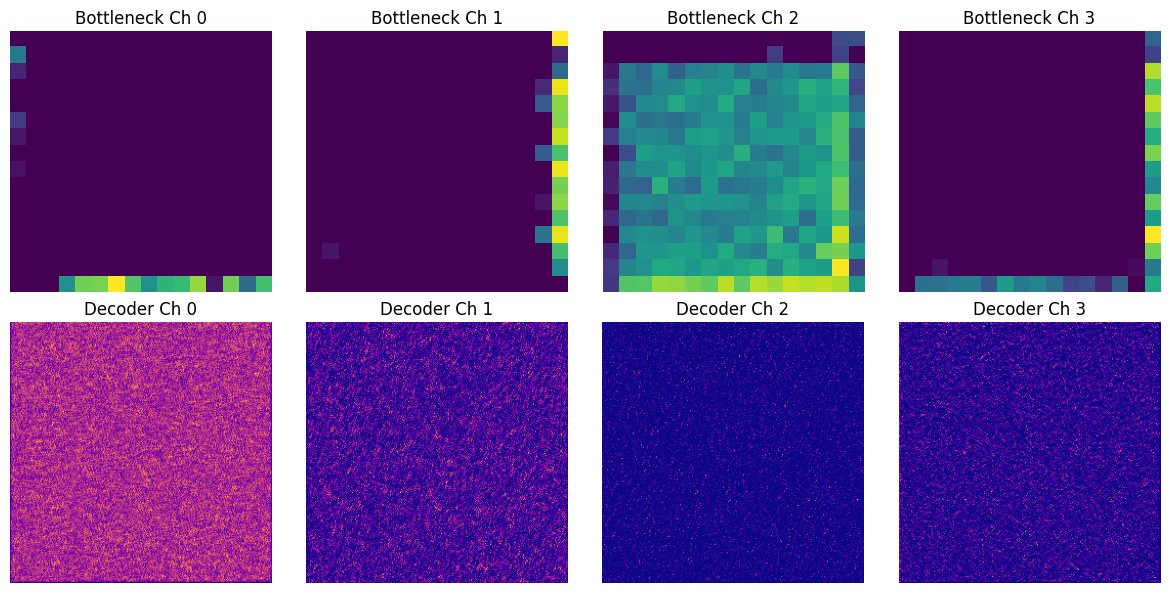

🧹 Hooks safely removed.


In [ ]:
import matplotlib.pyplot as plt

# Grab the first image's activations from batch (index 0)
bottleneck_feats = captured_features['bottleneck'][0]  # Shape: [1024, 16, 16]
decoder_feats = captured_features['final_decoder'][0]    # Shape: [64, 256, 256]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Plot first 4 channels of Bottleneck (Deep, abstract features)
for i in range(4):
    axes[0, i].imshow(bottleneck_feats[i].cpu().numpy(), cmap='viridis')
    axes[0, i].set_title(f"Bottleneck Ch {i}")
    axes[0, i].axis('off')

# Plot first 4 channels of Final Decoder (High-resolution spatial features)
for i in range(4):
    axes[1, i].imshow(decoder_feats[i].cpu().numpy(), cmap='plasma')
    axes[1, i].set_title(f"Decoder Ch {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Don't forget cleanup hygiene!
extractor.remove_hooks()
print(" Hooks safely removed.")

## testing the loss functions 

In [4]:
import torch
from src.lossess.SegmentationLoss import SegmentationLoss

# Create fake batch of data to test: 2 images of size 128x128
dummy_logits = torch.randn(2, 1, 128, 128, requires_grad=True) # Model output
dummy_targets = torch.randint(0, 2, (2, 1, 128, 128)).float()  # Real ground truth masks

In [5]:
# Instantiate our loss function
criterion = SegmentationLoss()
# Calculate loss
loss = criterion(dummy_logits, dummy_targets)

# Test backpropagation (making sure gradients pass through fine)
loss.backward()

print("--- SANITY CHECK PASSED ---")
print(f"Calculated Loss Value: {loss.item():.4f}")
print(f"Gradients computed successfully? {dummy_logits.grad is not None}")

--- SANITY CHECK PASSED ---
Calculated Loss Value: 0.4592
Gradients computed successfully? True
